In [1]:
import sys
from torch.profiler import profile, ProfilerActivity, record_function

TDECOMP_PATH = '..'
if not TDECOMP_PATH in sys.path:
    sys.path.append(TDECOMP_PATH)

from tdecomp.grad_proj.tensorgrad.config import TensorGRaDConfig, DataConfig, OptimizerConfig
import tdecomp.matrix.functional as F 
import pandas as pd

2026-03-06 13:33:26.018547: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 13:33:26.084298: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 13:33:27.601347: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Берём SmallLM 

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "arnir0/Tiny-LLM"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,  use_fast=False)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)


/tdecomp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 12/12 [00:00<00:00, 701.29it/s, Materializing param=model.norm.weight]                            


In [3]:
# train_imdb.py
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    pipeline
)
from datasets import load_dataset
import torch
# from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import numpy as np

model_name = "Qwen/Qwen2-0.5B-Instruct"
# model_name = 'arnir0/Tiny-LLM'
output_dir = "./qwen2-0.5b-imdb-finetuned"
# output_dir = './tiny-llm'
max_length = 512  # Maximum context length for each sample

# Use 4-bit quantization to drastically reduce memory usage
use_4bit = False
bnb_4bit_compute_dtype = "float16"
bnb_4bit_quant_type = "nf4"
use_nested_quant = False

# LoRA configuration for Parameter-Efficient Fine-Tuning
lora_r = 64
lora_alpha = 16
lora_dropout = 0.1

# Training arguments
num_train_epochs = 3
per_device_train_batch_size = 4
per_device_eval_batch_size = 4
gradient_accumulation_steps = 4
learning_rate = 2e-4
logging_steps = 10

print("Loading model and tokenizer...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=True)
# Set padding token if it doesn't exist
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model with 4-bit quantization if enabled
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)
if use_4bit:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=use_4bit,
        bnb_4bit_quant_type=bnb_4bit_quant_type,
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=use_nested_quant,
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",  # Automatically places layers on available GPUs
        trust_remote_code=True
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cuda:0", #auto
        torch_dtype=torch.float32,
        trust_remote_code=True
    )

# # Option 1: Tiny Shakespeare (literary text)
# dataset = load_dataset("tiny_shakespeare", split="train[:5%]")  # First 5%

# Option 2: CNN Daily Mail (news summaries) - smaller subset
# dataset = load_dataset("cnn_dailymail", "3.0.0", split="train[:100]")

# Option 3: Wikitext (Wikipedia articles) - small subset
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1000]")

# Option 4: Twitter Complaints (short text)
# dataset = load_dataset("twitter_complaints", split="train[:200]")

# Option 5: AG News (news articles)
# dataset = load_dataset("ag_news", split="train[:100]")

print(f"Dataset size: {len(dataset)}")
print(f"Dataset features: {dataset.features}")

# Preprocess the dataset based on its structure
def preprocess_dataset(examples):
    """Extract text from different dataset formats"""
    if 'text' in examples:
        return {"text": examples["text"]}
    elif 'article' in examples:  # CNN Daily Mail
        return {"text": examples["article"]}
    elif 'content' in examples:  # Some datasets
        return {"text": examples["content"]}
    elif 'sentence' in examples:  # Some sentence datasets
        return {"text": examples["sentence"]}
    else:
        # Try to use the first string column
        for key, value in examples.items():
            if isinstance(value[0], str):
                return {"text": examples[key]}
        return {"text": [str(x) for x in examples[list(examples.keys())[0]]]}

# Apply preprocessing
dataset = dataset.map(preprocess_dataset, batched=True)

# Filter out empty texts
dataset = dataset.filter(lambda example: len(example["text"].strip()) > 0)

# Tokenization function
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding=True,
        max_length=128,  # Reduced for tiny model
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

# Tokenize the dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Split dataset
train_test_split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split["train"]
eval_dataset = train_test_split["test"]

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")


# This will dynamically pad the batches during training
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # We are doing causal LM, not masked LM
)

# Load accuracy metric
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred): #if batch_eval_metrics=False in TrainingArguments - will be sended np.arrays on CPU not torch.Tensors!,
    logits, labels = eval_pred
    # Shift labels and predictions for causal LM (next token prediction)
    # Predictions are for the next token, so we shift labels accordingly
    shift_logits = logits[..., :-1, :] # (Batch size, Len of text bucket (aligned) -1, V - size of vocab)
    shift_labels = labels[..., 1:]
    
    # Flatten the tokens and get predictions
    predictions = np.argmax(shift_logits, axis=-1).flatten()
    labels = shift_labels.flatten()
    
    # Calculate accuracy, ignoring padding tokens (where label = -100)
    mask = labels != -100
    predictions = predictions[mask]
    labels = labels[mask]
    return accuracy_metric.compute(predictions=predictions, references=labels)

# ----------------------------
# 7. Training Arguments
# ----------------------------
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=per_device_eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    learning_rate=learning_rate,
    # logging_steps=logging_steps,
    logging_steps=5, #force model to make logs and WITHOUT eval (see table with each 5 step logs)
    save_steps=500,
    eval_strategy="no",
    #eval_steps=5, #every evaluate() in trainer consume lots cpu at the end to copy all metrics to cpu
    save_total_limit=2,
    load_best_model_at_end=True,
    eval_accumulation_steps=None, #if not batch eval, will send every eval_acum_steps [loses, preds, labels, inputs] on cpu inside epoch
    save_strategy="no", #'steps' by default
    #batch_eval_metrics=True, #will eval metrics every train batch! False - will eval metrics in the end of train epoch or in eval_steps=5
    report_to="mlflow",  # Disable external logging like Weights & Biases for simplicity
    fp16=False,  # Use mixed precision training #TODO try bf16
)

print("MODEL DEVICE", model.device)
print("DATASET DEVICE (CPU)", next(iter(train_dataset))['input_ids']) 

[INFO] Running in WANDB offline mode


Loading model and tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 317.00it/s, Materializing param=model.norm.weight]                              


Dataset size: 1000
Dataset features: {'text': Value('string')}
Training samples: 517
Validation samples: 130
MODEL DEVICE cuda:0
DATASET DEVICE (CPU) [284, 284, 284, 5994, 3145, 14506, 284, 284, 284, 715, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151

In [4]:
print(len(dataset))
dataset["text"][2]

647


" The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Honjou and composer Hitoshi Sakimoto both returned from previous entries , along with Valkyria Chronicles II director Takeshi Ozawa . A large team of writers handled the script . The game 's opening theme was sung by May 'n . \n"

In [5]:
print(train_test_split["train"]['text'][2])
print(train_test_split["train"]["input_ids"][2])
print(train_test_split["train"]["attention_mask"][2], len(train_test_split["train"]["attention_mask"][2]))
print(train_test_split["train"]["labels"][2])

 Fernandez 's first release of 2013 was Race 2 , an ensemble action thriller ( alongside Saif Ali Khan , John Abraham , Deepika Padukone , Ameesha Patel , and Anil Kapoor ) ) , described as the " cinematic equivalent of a trashy novel " by critic Rajeev Masand . She played Omisha , a femme fatale , a role which required her learn fencing and some acrobatics . The film emerged as a commercial success , with the domestic gross of more than ₹ 1 billion ( US $ 15 million ) . In a particularly scathing review , Saibal Chatterjee of NDTV wrote that both Fernandez and Padukone " strut around like wound @-@ up automatons that are all decked @-@ up but have nowhere to go . " Fernandez also appeared in an item number ( music video ) titled " Jaadu Ki Jhappi " for Prabhu Deva 's Ramaiya Vasta Vaiya . 

[82626, 364, 82, 1156, 4879, 315, 220, 17, 15, 16, 18, 572, 23659, 220, 17, 1154, 458, 39026, 1917, 53361, 320, 16263, 15854, 333, 14583, 24287, 1154, 3757, 36388, 1154, 18183, 11496, 25299, 3101, 

In [6]:
data_collator

DataCollatorForLanguageModeling(tokenizer=Qwen2Tokenizer(name_or_path='Qwen/Qwen2-0.5B-Instruct', vocab_size=151643, model_max_length=32768, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), mlm=False, whole_word_mask=False, mlm_probability=0.15, mask_replace_prob=0.8, random_replace_prob=0.1, pad_to_multiple_of=None, return_tensors='pt', seed=None)

ParallelTG, ULTG - это вспомогательные классы-фабрики, убирающие лишние настройки, чтобы было проще. 
Если понадобится более тонкая настройка -- смотрите TensorGRaDConfig и передавайте соответствующие поля (там есть **kwargs) 

In [7]:
from tdecomp.grad_proj.tensorgrad.prepared_tg import ParallelTG, ULTG
a, b = ParallelTG(model, 
                    F.cur, # svd_type можете зарегистрировать свои разложения матричные в модуле F, 
                    # а также просто `truncated_svd` и `randomized_svd`
                    (8, 0.5), # первый и второй ранги. может быть Number, тогда ранги ставятся одинкаовыми.
                    # 0 < float < 1 интерпретируется как доля параметров, int - непосредственно ранг
                                  n_train=len(train_dataset),
                                  batch_size=per_device_train_batch_size,
                                  scheduler='StepLR'
                                  )
    # compute_metrics=compute_metrics, # Uncomment for per-epoch metrics (slower)
a

TensorGRaD (
Parameter Group 0
    betas: (0.9, 0.999)
    correct_bias: True
    eps: 1e-06
    initial_lr: 0.0001
    lr: 0.0001
    weight_decay: 0.0

Parameter Group 1
    batch_size: 4
    betas: (0.9, 0.999)
    correct_bias: True
    dim: 2
    enforce_full_complex_precision: False
    epochs: 100
    eps: 1e-06
    galore_2d_proj_type: left
    initial_lr: 0.0001
    lambda_sparse: 0.05
    lr: 0.0001
    n_iter_max_tucker: 10
    optimizer_type: tensorgrad_sum
    proj_type: low_rank
    rank: 8
    reset_sparse_optimizer_states: False
    scale: 1.0
    scale_by_mask_ratio: True
    scheduler_T_max: 100
    second_proj_type: unstructured_sparse
    second_rank: 128
    second_scale: 1.0
    second_scale_by_mask_ratio: False
    second_sparse_ratio: 0.5
    second_sparse_type: topk
    sparse_ratio: 0.1
    sparse_type: topk
    svd_type: <function cur at 0x75ba44f27f40>
    training_samples: 517
    tucker_warm_restart: True
    type: galore
    update_proj_gap: 100
    updat

In [8]:
print(len(a.param_groups))
print(a.param_groups[0])
print(a.param_groups[1])

2


{'params': [Parameter containing:
tensor([ 6.7383e-02, -8.5938e-02,  1.1035e-01, -6.0547e-02,  5.1025e-02,
        -1.0010e-01, -8.5000e+00, -1.8750e-01,  1.0000e+01, -2.6250e+00,
         1.7285e-01,  1.1875e+01,  2.7656e+00,  2.0020e-01, -1.5039e-01,
         3.5469e+00, -4.0625e+00,  7.1562e+00, -7.6875e+00, -1.5469e+00,
        -3.4570e-01, -1.0391e+00, -4.1562e+00,  3.8906e+00, -4.6875e+00,
         2.6875e+00, -5.5938e+00, -8.3203e-01,  2.4375e+00,  1.6562e+00,
        -2.3438e-01,  8.5156e-01,  6.2256e-02,  2.2583e-02,  1.3733e-02,
        -8.3496e-02,  1.6211e-01, -1.5918e-01, -6.5938e+00,  8.1055e-02,
        -1.5234e-01,  3.8438e+00, -3.6377e-02, -1.0875e+01,  2.2188e+00,
        -2.3906e+00, -1.2344e+00,  9.2500e+00,  9.6875e-01,  4.1562e+00,
         2.4531e+00, -4.6875e+00,  3.8906e+00, -3.6250e+00,  2.1875e+00,
        -4.5312e+00,  1.0312e+01, -4.4375e+00,  4.0312e+00,  2.6875e+00,
        -2.5977e-01, -1.3906e+00, -1.1250e+00,  9.6875e-01,  7.8613e-02,
        -7.6660e-

In [9]:
[print(tens.shape) for tens in a.param_groups[0]['params']]
print(len(a.param_groups[0]['params']))

torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size([896])
torch.Size([128])
torch.Size([128])
torch.Size([896])
torch.Size([896])
torch.Size

In [10]:


from examples.experiment_utils import print_param_sizes


print_param_sizes(a, 1)

ImportError: cannot import name 'print_param_sizes' from 'examples.experiment_utils' (/tdecomp/examples/../examples/experiment_utils.py)

In [18]:
from tdecomp.grad_proj.tensorgrad.prepared_tg import ParallelTG, ULTG

import importlib
from examples import experiment_utils
from tdecomp.grad_proj.tensorgrad.projectors import update_gap_scheduler
importlib.reload(experiment_utils)
import tdecomp.grad_proj.tensorgrad.prepared_tg
importlib.reload(tdecomp.grad_proj.tensorgrad.prepared_tg)
# importlib.reload(prepared_tg)

rank = 896
optimizer = ParallelTG(model, #TODO check that 0.5 не попадает в sparse_type а попадает в second_rank и затем никуда 
                    None, #will automatically partial(tl.truncated_svd, n_eigenvecs=min(tl.shape(tensor)))
                      # svd_type можете зарегистрировать свои разложения матричные в модуле F, 
                    # а также просто `truncated_svd` и `randomized_svd`
                    (rank, 0.5), # первый и второй ранги. может быть Number, тогда ранги ставятся одинкаовыми.
                    # 0 < float < 1 интерпретируется как доля параметров, int - непосредственно ранг
                                  n_train=len(train_dataset),
                                  batch_size=per_device_train_batch_size,
                                  scheduler='StepLR',
                                  update_proj_gap=10,
                                  tensorgrad_sum_lambda_sparse=1
                                  )

optimizer = ULTG(model, #TODO check that 0.5 не попадает в sparse_type а попадает в second_rank и затем никуда 
                    None, #will automatically partial(tl.truncated_svd, n_eigenvecs=min(tl.shape(tensor)))
                      # svd_type можете зарегистрировать свои разложения матричные в модуле F, 
                    # а также просто `truncated_svd` и `randomized_svd`
                    (rank, 0.5), # первый и второй ранги. может быть Number, тогда ранги ставятся одинкаовыми.
                    # 0 < float < 1 интерпретируется как доля параметров, int - непосредственно ранг
                                  n_train=len(train_dataset),
                                  batch_size=per_device_train_batch_size,
                                  scheduler='StepLR',
                                  update_proj_gap=10,
                                  tensorgrad_sum_lambda_sparse=1
                                  )
print("optimizer rank", optimizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, #internally it creates Accelerator(torch.DataLoader(dataset)) that on gpu
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    optimizers=optimizer,
    compute_metrics=compute_metrics, # Uncomment for per-epoch metrics (slower)
    callbacks=[experiment_utils.UpdateGapMLflowCallback(), 
               experiment_utils.SystemMetricsCallback(),
               ]

)

trainer.add_callback(experiment_utils.PerplexityCallback(trainer.get_eval_dataloader(), max_batches=5, eval_every_n_steps=5))
#TODO FIX!
trainer.compute_loss_func
trainer.compute_loss

optimizer rank (TensorGRaD (
Parameter Group 0
    betas: (0.9, 0.999)
    correct_bias: True
    eps: 1e-06
    initial_lr: 0.0001
    lr: 0.0001
    weight_decay: 0.0

Parameter Group 1
    batch_size: 4
    betas: (0.9, 0.999)
    correct_bias: True
    dim: 2
    enforce_full_complex_precision: False
    epochs: 100
    eps: 1e-06
    galore_2d_proj_type: left
    initial_lr: 0.0001
    lambda_sparse: 1
    lr: 0.0001
    n_iter_max_tucker: 10
    optimizer_type: tensorgrad
    proj_type: unstructured_sparse
    rank: 128
    reset_sparse_optimizer_states: False
    scale: 1.0
    scale_by_mask_ratio: True
    scheduler_T_max: 100
    second_proj_type: low_rank
    second_rank: 896
    second_scale: 1.0
    second_scale_by_mask_ratio: False
    second_sparse_ratio: 0.25
    second_sparse_type: topk
    sparse_ratio: 0.5
    sparse_type: topk
    svd_type: None
    training_samples: 517
    tucker_warm_restart: True
    type: galore
    update_proj_gap: 10
    update_proj_gap_end: 1

<bound method Trainer.compute_loss of <transformers.trainer.Trainer object at 0x75b9bd1ed660>>

In [ ]:
train_loader = trainer.get_train_dataloader()
batch = next(iter(train_loader))
print(tokenizer.decode([2, 1, 29871, 13, 450], skip_special_tokens=False))
print(tokenizer.decode(batch['input_ids'][2]))
print(batch['input_ids'][0].shape)
print(batch["input_ids"].shape)
print(batch["input_ids"])

#"NING.de
 = = In the Union Navy = = 
<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>

In [ ]:
! timeout 2 bash -lc 'echo > /dev/tcp/172.19.0.1/5000' && echo OK || echo FAIL

OK


In [ ]:
! timeout 2 bash -lc 'echo > /dev/tcp/localhost/5000' && echo OK || echo FAIL

bash: connect: Connection refused
bash: line 1: /dev/tcp/localhost/5000: Connection refused
FAIL


In [ ]:
! timeout 2 bash -lc 'echo > /dev/tcp/mlflow-network/5000' && echo OK || echo FAIL

bash: line 1: mlflow-network: Temporary failure in name resolution
bash: line 1: /dev/tcp/mlflow-network/5000: Invalid argument
FAIL


In [ ]:
import mlflow
import mlflow.pytorch
from mlflow.server import get_app_client
import os

mlflow.set_tracking_uri("http://172.19.0.1:5000")
mlflow.set_experiment("my-first-experiment-glazkov")
# client = get_app_client("basic-auth", "http://172.19.0.1:5000")
# client.create_user(username="minio", password="minio123")
# # mlflow.export

os.environ["AWS_ACCESS_KEY_ID"] = "minio"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minio123"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://172.19.0.1:9000" #https://github.com/mlflow/mlflow/issues/2150

if (False):
    with mlflow.start_run(run_name="particular-run-name"):
        # Log model with signature and input example
        

        mlflow.log_params({'param1': 'lal', 'my_lal_param': 'lol'})

        mlflow.log_metric("accuracy", 150)

        # Optional: Set a tag that we can use to remind ourselves what this run was for
        mlflow.set_tag("Training Info", "Basic LR model for iris data")

        mlflow.pytorch.log_model(
            model,
            name="pytorch_model_example2_glazkov",
        )

        model5 = RandomForestRegressor()
        mlflow.sklearn.log_model(
            model5,
            name="rand_forest",
        )

In [ ]:
top_models = mlflow.search_logged_models(
    experiment_ids=["58"],
)
top_models

,artifact_location,creation_timestamp,experiment_id,last_updated_timestamp,metrics,model_id,model_type,name,params,source_run_id,status,status_message,tags
0,s3://mlflow/58/models/m-63b646fd23834511b207c5...,1771592656118,58,1771592665542,"[<Metric: dataset_digest=None, dataset_name=No...",m-63b646fd23834511b207c54ea211d622,,pytorch_model_example2_glazkov,"{'my_lal_param': 'lol', 'param1': 'lal'}",b7ec971e009d4250823a16b9f87cf87c,FAILED,,{'mlflow.source.name': 'tensorgrad_run_draft.i...
1,s3://mlflow/58/models/m-ca91e4dbb8cf4ce5a62660...,1771351309768,58,1771351313168,"[<Metric: dataset_digest=None, dataset_name=No...",m-ca91e4dbb8cf4ce5a626606448e344ad,,rand_forest,"{'my_lal_param': 'lol', 'param1': 'lal'}",871173a5c8db4fee92da4954c3d9588a,READY,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
2,s3://mlflow/58/models/m-cb9588b44cdb44fa9f5763...,1771351300239,58,1771351309674,"[<Metric: dataset_digest=None, dataset_name=No...",m-cb9588b44cdb44fa9f5763028fd5d7a5,,pytorch_model_example2_glazkov,"{'my_lal_param': 'lol', 'param1': 'lal'}",871173a5c8db4fee92da4954c3d9588a,READY,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
3,s3://mlflow/58/models/m-bbd72ebd80a24671889975...,1771351241806,58,1771351244135,[],m-bbd72ebd80a2467188997500552a1209,,rand_forest,{},,READY,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
4,s3://mlflow/58/models/m-c042b23b330045d38fd8e8...,1771351227391,58,1771351227414,[],m-c042b23b330045d38fd8e8a321b47b42,,rand_forest,{},,FAILED,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
5,s3://mlflow/58/models/m-5096569ed5a54301a9523d...,1771348062617,58,1771348071857,"[<Metric: dataset_digest=None, dataset_name=No...",m-5096569ed5a54301a9523ddaffa9286a,,pytorch_model_example2_glazkov,"{'my_lal_param': 'lol', 'param1': 'lal'}",3457d9817ca84e01a09d9f4eee7d660c,READY,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
6,s3://mlflow/58/models/m-4929d3f22ed34e00b18ec4...,1771346306994,58,1771346317619,[],m-4929d3f22ed34e00b18ec4c4bef8d675,,pytorch_model_example_glazkov,{},780eaea33138427f81eea00924473b6f,READY,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
7,s3://mlflow/58/models/m-21415c0700334ed0ba4e90...,1771345730482,58,1771345739271,[],m-21415c0700334ed0ba4e902df23c3eaf,,pytorch_model_example_glazkov,{},15b798a6e8a54405938eda034c82b817,FAILED,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
8,s3://mlflow/58/models/m-027ad243e0624e25a38850...,1771345629220,58,1771345640634,[],m-027ad243e0624e25a38850dab86ca5ed,,pytorch_model_example_glazkov,{},c7f350d3c35d49a9ac533fa661636043,FAILED,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."
9,s3://mlflow/58/models/m-6615fc94a59444b992ad1c...,1771343278891,58,1771343290470,[],m-6615fc94a59444b992ad1ced7b26b43b,,pytorch_model_example_glazkov,{},c83c79298d4041d083bb5ce7f6d53419,FAILED,,"{'mlflow.source.name': 'tensorgrad_run.ipynb',..."


In [ ]:
# model5 = mlflow.sklearn.load_model("runs:/871173a5c8db4fee92da4954c3d9588a/rand_forest")

In [ ]:
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

In [ ]:
#INNER CODE FOR TrainingArguments!
# class IntervalStrategy(ExplicitEnum):
#     NO = "no"
#     STEPS = "steps"
#     EPOCH = "epoch"


# class SaveStrategy(ExplicitEnum):
#     NO = "no"
#     STEPS = "steps"
#     EPOCH = "epoch"
#     BEST = "best"

In [19]:
### for debug2
# trainer.step()
results = trainer.train()


### Using Composite Projector Configuration ###
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x75b9c104a9b0>
UnstructuredSparseProjector initialized with sparse_ratio=0.5, sparse_type=topk, scale_by_mask_ratio=True
    => First projector: unstructured_sparse
rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
GaLoreProjector initialized with rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
    => Second projector: low_rank


/tdecomp/.venv/lib/python3.10/site-packages/tensorly/backend/__init__.py:202: UserWarning: An output with one or more elements was resized since it had shape [896, 896], which does not match the required output shape [151936, 896]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  return getattr(


### Using Composite Projector Configuration ###
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x75b9c1007fa0>
UnstructuredSparseProjector initialized with sparse_ratio=0.5, sparse_type=topk, scale_by_mask_ratio=True
    => First projector: unstructured_sparse
rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
GaLoreProjector initialized with rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
    => Second projector: low_rank
### Using Composite Projector Configuration ###
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x75b9c1006230>
UnstructuredSparseProjector initialized with sparse_ratio=0.5, sparse_type=topk, scale_by_mask_ratio=True
    => First projector: unstructured_sparse
rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, 

/tdecomp/.venv/lib/python3.10/site-packages/tensorly/backend/__init__.py:202: UserWarning: An output with one or more elements was resized since it had shape [896, 896], which does not match the required output shape [4864, 896]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  return getattr(


### Using Composite Projector Configuration ###
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x75b9bd1eec50>
UnstructuredSparseProjector initialized with sparse_ratio=0.5, sparse_type=topk, scale_by_mask_ratio=True
    => First projector: unstructured_sparse
rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
GaLoreProjector initialized with rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, support_complex=True
    => Second projector: low_rank
### Using Composite Projector Configuration ###
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x75b9bd1ee830>
UnstructuredSparseProjector initialized with sparse_ratio=0.5, sparse_type=topk, scale_by_mask_ratio=True
    => First projector: unstructured_sparse
rank=896, scale=1.0, galore_2d_proj_type=left, activation_checkpointing=False, 

KeyboardInterrupt: 

## See on grad and it's compressed version in optimizer

In [ ]:
import torchinfo
torchinfo.summary(model)

Layer (type:depth-idx)                             Param #
Qwen2ForCausalLM                                   --
├─Qwen2Model: 1-1                                  --
│    └─Embedding: 2-1                              136,134,656
│    └─ModuleList: 2-2                             --
│    │    └─Qwen2DecoderLayer: 3-1                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-2                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-3                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-4                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-5                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-6                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-7                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-8                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-9                 14,912,384
│    │    └─Qwen2DecoderLayer: 3-10                14,912,384
│    │    └─Qwen2DecoderLayer: 3-11                14,912,384
│    │    └─Qwen2DecoderLayer: 3-1

In [ ]:
# def recover_norm_grad(
#     p_old: torch.Tensor,
#     p_new: torch.Tensor,
#     group
# ):
#     step_size = -group["lr"] * step_size if group.get("correct_bias", True) else -group["lr"]
#     torch.mul(norm_grad, step_size, out=norm_grad)
#     p.add_(norm_grad)
    
#     del norm_grad  # Free memory immediately
#     torch.cuda.empty_cache()
#     if group["weight_decay"] > 0.0:
#         p.add_(p, alpha=(-group["lr"] * group["weight_decay"]))

#     # g = (p_new / d - p_old) / s
#     return (p_new / d - p_old) / s

In [22]:
trainer.model.train()

# 1) Берём batch
train_loader = trainer.get_train_dataloader()
batch = next(iter(train_loader))
batch = trainer._prepare_inputs(batch)  # перенос на нужный device

# 2) Считаем loss + backward через внутреннюю логику Trainer
loss = trainer.training_step(trainer.model, batch)

# На этом этапе градиенты уже в параметрах и НЕ обнулены
p = next(trainer.model.parameters())
print("grad is None?", p.grad is None)

# 3) Если нужно — делаем шаг оптимизатора вручную
# trainer.optimizer.step()

# 4) И специально НЕ делаем trainer.optimizer.zero_grad()

grad is None? False


In [23]:
# p = next(iter(model.parameters()))
print(p.grad.shape, torch.numel(p.grad))
print(p.grad)
aprox_grad = torch.zeros(p.grad.shape[0], p.grad.shape[1], device="cuda:0")
optimizer[0].step(save_grad_for_tracing=aprox_grad, p_for_tracing = p)
print(aprox_grad)

torch.Size([151936, 896]) 136134656
tensor([[-6.9310e-07,  6.5078e-07, -1.8538e-07,  ...,  3.9471e-07,
          5.0074e-07, -3.5817e-07],
        [-5.0704e-06,  2.8999e-06, -1.3651e-05,  ...,  2.0164e-05,
          9.3107e-06,  9.8893e-07],
        [-8.8336e-08,  1.6263e-07,  1.3372e-07,  ..., -9.5923e-10,
          9.8950e-08,  1.3637e-07],
        ...,
        [-1.0141e-09,  2.7735e-09, -8.2189e-10,  ...,  6.3810e-10,
          9.8855e-10,  3.3017e-11],
        [-1.0156e-09,  2.7756e-09, -8.2264e-10,  ...,  6.3888e-10,
          9.8962e-10,  3.3143e-11],
        [-1.0157e-09,  2.7761e-09, -8.2323e-10,  ...,  6.3894e-10,
          9.8994e-10,  3.2903e-11]], device='cuda:0')
its match
shape torch.Size([151936, 896])
second (low rank?) grad shape (compressed) torch.Size([896, 896])
step size 0.1524191271813757


KeyboardInterrupt: 

In [24]:
print(torch.linalg.norm(p.grad ))
print(torch.linalg.norm(aprox_grad))
print(torch.linalg.norm(p.grad - aprox_grad)) #it's okay, before norm was 300-3000 of aprox_grad

tensor(0.8990, device='cuda:0')
tensor(0.7320, device='cuda:0')
tensor(0.5216, device='cuda:0')


In [25]:
print("Состояние для этого параметра")
trainer.optimizer.state[p]

Состояние для этого параметра


{'step': 2,
 'id': 121,
 'total_params': 136134656,
 'first_proj': <tdecomp.grad_proj.tensorgrad.projectors.tensor_unstructured_sparse_projector.TensorGradUnstructuredProjector at 0x7ce462f9e950>,
 'second_proj': <tdecomp.grad_proj.tensorgrad.projectors.galore_projector.GaLoreProjector at 0x7ce462f9e590>,
 'sparse_is_first': True,
 'first_exp_avg': tensor([-1.6615e-07, -1.1834e-06,  8.6118e-08,  ..., -5.3713e-10,
         -2.8707e-09, -4.7483e-10], device='cuda:0'),
 'first_exp_avg_sq': tensor([9.5192e-15, 1.3862e-13, 5.6942e-16,  ..., 1.9809e-20, 5.8259e-19,
         1.6064e-20], device='cuda:0'),
 'second_exp_avg': tensor([[-4.6242e-04,  8.5709e-04,  2.6764e-04,  ...,  1.3867e-04,
          -1.2051e-04,  4.8589e-04],
         [-8.7662e-04, -4.6297e-04,  1.6313e-04,  ...,  5.9569e-05,
           2.3878e-04,  6.1128e-05],
         [ 7.8678e-04,  7.6019e-05,  5.1643e-04,  ...,  3.1218e-04,
          -2.1161e-04, -1.9156e-04],
         ...,
         [ 4.8693e-09, -9.9247e-09, -1.9673e-08

In [59]:
results

TrainOutput(global_step=99, training_loss=4.982904511268693, metrics={'train_runtime': 9.5787, 'train_samples_per_second': 161.922, 'train_steps_per_second': 10.335, 'total_flos': 8153535430656.0, 'train_loss': 4.982904511268693, 'epoch': 3.0})

In [55]:
# torch.cuda.empty_cache()
print("Starting training...")
mlflow.end_run()
with mlflow.start_run(run_name="another-run-train"):
    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], 
                  with_stack=True, 
                record_shapes=True,
                #experimental_config=torch._C._profiler._ExperimentalConfig(verbose=True),
                ) as profiler:
        with record_function("Record Train!"):
            results = trainer.train()

2026/02/20 20:42:44 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Starting training...
### Using Composite Projector Configuration ###
    => Swapping projectors to ensure smaller one is first
    => Sizes after swap: first=0.25, second=8.0
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x7d73a1f29220>
UnstructuredSparseProjector initialized with sparse_ratio=0.25, sparse_type=topk, scale_by_mask_ratio=False
    => First projector: unstructured_sparse
    => Second projector: low_rank
### Using Composite Projector Configuration ###
    => Swapping projectors to ensure smaller one is first
    => Sizes after swap: first=0.25, second=8.0
Update gap scheduler: <tdecomp.grad_proj.tensorgrad.projectors.update_gap_scheduler.UpdateGapScheduler object at 0x7d73713c49b0>
UnstructuredSparseProjector initialized with sparse_ratio=0.25, sparse_type=topk, scale_by_mask_ratio=False
    => First projector: unstructured_sparse
    => Second projector: low_rank
### Using Composite Projector Configurati

Step,Training Loss
5,4.742763
10,4.779536
15,4.750181


2026/02/20 20:43:07 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/02/20 20:43:07 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run another-run-train at: http://172.19.0.1:5000/#/experiments/58/runs/796b989b5039459d8697ad9301fd7586
🧪 View experiment at: http://172.19.0.1:5000/#/experiments/58


KeyboardInterrupt: 

In [44]:
print(len(trainer.train_dataset) / 4 / 4) #total steps (4 - batch, 4 -accumulate batch)
print(len(trainer.eval_dataset) / 4) #when evaluate, only consider 4 sample/batch, without grad accumulation
# this eval goes every 5 steps (it consume many cpu)
# also 

32.3125
32.5


In [36]:
results #if without 

TrainOutput(global_step=99, training_loss=4.900089013456094, metrics={'train_runtime': 197.5015, 'train_samples_per_second': 7.853, 'train_steps_per_second': 0.501, 'total_flos': 8153535430656.0, 'train_loss': 4.900089013456094, 'epoch': 3.0})

In [ ]:
torch.cuda.device_count()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 192)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=False)
          (k_proj): Linear(in_features=192, out_features=96, bias=False)
          (v_proj): Linear(in_features=192, out_features=96, bias=False)
          (o_proj): Linear(in_features=192, out_features=192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=192, out_features=1024, bias=False)
          (up_proj): Linear(in_features=192, out_features=1024, bias=False)
          (down_proj): Linear(in_features=1024, out_features=192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((192,), eps=1e-05)
    (rotary_emb): LlamaRotaryEm

In [22]:
print(model)
len(list(model.parameters()))    
for p in model.parameters():
    print(p)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 192)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=False)
          (k_proj): Linear(in_features=192, out_features=96, bias=False)
          (v_proj): Linear(in_features=192, out_features=96, bias=False)
          (o_proj): Linear(in_features=192, out_features=192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=192, out_features=1024, bias=False)
          (up_proj): Linear(in_features=192, out_features=1024, bias=False)
          (down_proj): Linear(in_features=1024, out_features=192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((192,), eps=1e-05)
    (rotary_emb): LlamaRotaryEm

In [23]:
torch.embedding()


TypeError: embedding() missing 2 required positional argument: "weight", "indices"

In [24]:
for name, module in model.named_modules():
    if (len(list(module.children())) == 0):
        print(name)
        if (hasattr(module, 'weight')):
            print("weight - true")
        else: print('weight - false')

model.embed_tokens
weight - true
model.layers.0.self_attn.q_proj
weight - true
model.layers.0.self_attn.k_proj
weight - true
model.layers.0.self_attn.v_proj
weight - true
model.layers.0.self_attn.o_proj
weight - true
model.layers.0.mlp.gate_proj
weight - true
model.layers.0.mlp.up_proj
weight - true
model.layers.0.mlp.down_proj
weight - true
model.layers.0.mlp.act_fn
weight - false
model.layers.0.input_layernorm
weight - true
model.layers.0.post_attention_layernorm
weight - true
model.norm
weight - true
model.rotary_emb
weight - false
lm_head
weight - true


In [166]:
model.model.layers[0].mlp

LlamaMLP(
  (gate_proj): Linear(in_features=192, out_features=1024, bias=False)
  (up_proj): Linear(in_features=192, out_features=1024, bias=False)
  (down_proj): Linear(in_features=1024, out_features=192, bias=False)
  (act_fn): SiLUActivation()
)

In [151]:
# model.named_children()
# model.children()

In [122]:
print(len(list(model.parameters(recurse=False))))
print(len(list(model.parameters(recurse=True))))

0
12


In [137]:
type(list(model.named_modules())[2][1].parameters(recurse=False).__iter__().__next__())

torch.nn.parameter.Parameter

In [142]:
print(len(model.state_dict()))
model.state_dict()

12


OrderedDict([('model.embed_tokens.weight',
              tensor([[ 5.1498e-04,  8.9216e-04, -9.9945e-04,  ..., -4.0936e-04,
                        7.7057e-04, -1.8244e-03],
                      [-2.7274e-03, -3.7239e-04,  5.9496e-04,  ...,  1.9564e-03,
                       -2.4081e-04,  1.3295e-03],
                      [-1.2164e-01, -2.3468e-02, -2.1957e-02,  ...,  5.3902e-03,
                        6.3896e-03, -3.7174e-03],
                      ...,
                      [-9.5367e-03, -1.9321e-03, -1.4229e-02,  ..., -1.4503e-02,
                       -1.3895e-03,  1.0963e-02],
                      [ 1.4544e-03, -5.3291e-03,  5.6076e-03,  ..., -2.0676e-03,
                        2.1148e-04,  9.4299e-03],
                      [-5.4283e-03,  6.3539e-05,  1.1017e-02,  ..., -2.2106e-03,
                       -3.1769e-02,  3.9093e-02]], device='cuda:0')),
             ('model.layers.0.self_attn.q_proj.weight',
              tensor([[ 0.0065, -0.0371, -0.0055,  ..., -0.0308, -0.

In [25]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
comment="partial with trace"
profiler.export_chrome_trace(f"profile_{timestamp}_{comment}.json")

input_ids
attention_mask
labels


In [31]:
batch = next(iter(trainer.get_train_dataloader()))
print("batch", batch) #on cuda!
print("keys", [k for k in batch.keys()])
outputs = model(**{k: v.to(model.device) for k, v in batch.items()})
print(outputs.loss, outputs.keys())
print(outputs)
print(outputs.loss)

# compute_metrics(outputs)
# loss, logits = outputs
# outputs.logits
print(outputs.loss, outputs.keys())

batch {'input_ids': tensor([[    1, 29871,   450, 11143, 28908,   379, 12050,  6726,  2056,  6054,
           347,  1919, 29871, 29896, 29929, 29941, 29941, 29871,    13,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,   

tensor(5.2843, device='cuda:0', grad_fn=<NllLossBackward0>)

In [40]:
# Check that outputs predict next-token shift
batch = next(iter(trainer.get_train_dataloader()))
device = next(model.parameters()).device
batch = {k: v.to(device) for k, v in batch.items() if torch.is_tensor(v)}

with torch.no_grad():
    outputs = model(**batch)
    logits = outputs.logits

input_ids = batch["input_ids"]
labels = batch.get("labels", input_ids)

pred_ids = logits.argmax(dim=-1)

label_ids = labels.clone()
if (label_ids == -100).any():
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    label_ids[label_ids == -100] = pad_id

print("input_0:")
print(tokenizer.decode(input_ids[0].tolist(), skip_special_tokens=False))
print("pred_0_shifted:")
print(tokenizer.decode(pred_ids[0][:-1].tolist(), skip_special_tokens=False))
print("label_0_shifted:")
print(tokenizer.decode(label_ids[0][1:].tolist(), skip_special_tokens=False))

input_0:
<s>  The Little Picture Hymn Book ; Blackie , 1933 
</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>
pred_0_shifted:
1ft Rock ofits of is ), 1990
1-                                                                                                            
label_0_shifted:
 The Little Picture Hymn Book ; Blackie , 1933 
</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s><

In [39]:
outputs[1][0]

tensor([[ -6.1339,  -6.1004,   2.3776,  ...,  -5.7274,  -6.1157,  -5.7781],
        [ -7.6140,  -7.6041,   0.6126,  ...,  -6.1842,  -7.3148,  -6.1878],
        [-10.4658, -10.4514,  -5.7885,  ...,  -9.3670, -10.2480,  -9.1823],
        ...,
        [-11.1064, -11.0761,   1.3310,  ...,  -9.8957, -10.7812,  -9.8636],
        [-11.2702, -11.2394,   1.2075,  ..., -10.0237, -10.9398, -10.0077],
        [-11.5166, -11.4851,   0.9504,  ..., -10.1993, -11.1778, -10.2065]],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [28]:
trainer.evaluate()

2026/02/20 15:06:53 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/02/20 15:06:53 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics

{'eval_loss': 5.539211273193359,
 'eval_model_preparation_time': 0.0015,
 'eval_runtime': 0.2566,
 'eval_samples_per_second': 506.54,
 'eval_steps_per_second': 128.583}

In [28]:
from torch import device
import transformers
transformers.tokenization_utils_base.BatchEncoding

prompt = "Hi, hopw are you?" #onn
inputs = tokenizer(prompt, return_tensors="pt") #on cpu, understandable
print(inputs.input_ids )
inputs = inputs.to(torch.device("cuda:0")) #supports to() method! BatchEncoding(dict)
print(inputs.input_ids)
type(inputs)

tensor([[    1,  6324, 29892,  8171, 29893,   526,   366, 29973]])
tensor([[    1,  6324, 29892,  8171, 29893,   526,   366, 29973]],
       device='cuda:0')


transformers.tokenization_utils_base.BatchEncoding

In [59]:
trainer.train_dataset.next()

AttributeError: 'Dataset' object has no attribute 'next'

In [53]:
type(list(model.parameters())[0].data)

torch.Tensor

In [56]:
outputs = model.generate(**inputs, max_new_tokens=100, do_sample=True, top_k=50, top_p=0.95)
outputs #goes without DataLoader, dont have loss function and so on

tokenizer.decode(outputs)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


["<s> Hi, hopw are you?. It isn't that it will take it too hard. So I have the time to give them my eyes a nice bit and be careful now to make their own money more appealing as well.\nThe point at hand was the point where the shots went over and a day, and I saw this day. They told me that they would be very proud of them as a couple of years ago I had to take back a day in the evening after my last storm. The last morning"]

In [1]:
import torch
print(torch.cuda.empty_cache())
print(torch.cuda.memory_allocated(0))
print(torch.cuda.memory_reserved(0))
print(torch.cuda.max_memory_reserved(0))
print(torch.cuda.memory_stats(0))
print(torch.cuda.memory_snapshot())

None
0
0
0
OrderedDict()
[]


In [4]:
torch.nn.functional.log_softmax(torch.tensor([[10.0, -100]]), dim=-1) 

tensor([[   0., -110.]])

In [ ]:
import itertools

s = "In Hartford , ppointment at losing Francis . The Hartford fans initially booed him to show their dissatisfaction with the trade . He scored 16 points in 13 regular season games to finish the season with 110 points combined between the Penguins and Whalers , and was the team 's best player in their first round loss to the Boston Bruins in the 1991 Stanley Cup Playoffs . He initially accepted an invitation to join the Canadian team at the 1991 Canada Cup ,"
print(len(s.split(" ")))
inputs = tokenizer(s, return_tensors="pt").to(model.device)
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))
print(len(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])))


outputs = model.generate(
        **inputs,
        max_length=128,
        #max_new_tokens = 30,
        temperature=0.9,
        num_beams=5,
        top_k=50,
        top_p=0.95,
        no_repeat_ngram_size=3,
        do_sample=True,
        # use_cache=False
    )


out_tokens = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(out_tokens)

gen_ids = inputs["input_ids"] 
print(gen_ids) # (1, L_gen)

dataloader = trainer.get_eval_dataloader()

batch0 = next(iter(dataloader))
print("batch0", batch0)

#CHANGED (corrected) FUNCTION FROM small_llm.ipynb
with torch.no_grad():
    logits = model(**batch0).logits  # (1, L_gen, V)
    # print("logits start", logits[0], "end")
    shift_logits = logits[..., :-1, :].contiguous()      # (1, L_gen-1, V)
    shift_labels = batch0['labels'][..., 1:].contiguous()         # (1, L_gen-1)
    shift_mask = batch0['attention_mask'][..., 1:].contiguous().bool()
    print("shift logits", shift_logits.shape)
    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)      # (1, L_gen-1, V)
    shift_labels = torch.clamp(shift_labels, min=0)
    print("log probs", log_probs.shape)
    target_logprobs = log_probs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)  # (1, L_gen-1)
    print("target logprobs", target_logprobs.shape)
    print("shift mask", shift_mask.shape)
    masked_logprobs = target_logprobs.masked_select(shift_mask)
    total_nll = - masked_logprobs.sum().item()
    total_tokens = shift_mask.sum().item() #(0)
    # защититься от деления на ноль
    ppl = float(np.exp(total_nll / max(1, total_tokens)))
print(f"Perplexity (generated): {ppl:.3f}  nll={total_nll:.3f}  tokens={total_tokens}")


total_nll = 0
total_tokens = 0

#FUNCTION USED IN EXPERIMENT_UTILS (before debug returned perplexity 200000 for tiny llm, now ~ 247)
with torch.no_grad():
    for batch in itertools.islice(dataloader, 1):
        batch = {k: v for k, v in batch.items()}
        outputs = model(**batch) #in that mode model will create the same amount of logits as it was in batch
        logits = outputs.logits
        labels = batch["labels"]
        #SHIFT
        logits = logits[..., :-1, :].contiguous()
        labels = labels[..., 1:].contiguous()
        shift_mask = batch['attention_mask'][..., 1:].contiguous().bool()
        log_probs = -torch.nn.functional.log_softmax(logits, dim=-1)
        labels = torch.clamp(labels, min=0)
        #print("labels shape", labels.shape, "logprobs shape", log_probs.shape)
        nll_loss = log_probs.gather(dim=-1, index=labels.unsqueeze(-1)).squeeze(-1) # (1, L_gen-1)
        
        masked_logprobs = nll_loss.masked_select(shift_mask)
        total_nll += masked_logprobs.sum().item() #total per batch, not per dim=-1
        total_tokens += shift_mask.sum()

    ppl = torch.exp(total_nll / total_tokens).item()
    print("perplexity 2:", ppl)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


84
['<s>', '▁In', '▁Hart', 'ford', '▁,', '▁p', 'point', 'ment', '▁at', '▁losing', '▁Francis', '▁.', '▁The', '▁Hart', 'ford', '▁fans', '▁initially', '▁bo', 'o', 'ed', '▁him', '▁to', '▁show', '▁their', '▁diss', 'atisf', 'action', '▁with', '▁the', '▁trade', '▁.', '▁He', '▁scored', '▁', '1', '6', '▁points', '▁in', '▁', '1', '3', '▁regular', '▁season', '▁games', '▁to', '▁finish', '▁the', '▁season', '▁with', '▁', '1', '1', '0', '▁points', '▁combined', '▁between', '▁the', '▁P', 'engu', 'ins', '▁and', '▁Wh', 'al', 'ers', '▁,', '▁and', '▁was', '▁the', '▁team', "▁'", 's', '▁best', '▁player', '▁in', '▁their', '▁first', '▁round', '▁loss', '▁to', '▁the', '▁Boston', '▁Bru', 'ins', '▁in', '▁the', '▁', '1', '9', '9', '1', '▁Stanley', '▁Cup', '▁Play', 'offs', '▁.', '▁He', '▁initially', '▁accepted', '▁an', '▁inv', 'itation', '▁to', '▁join', '▁the', '▁Canadian', '▁team', '▁at', '▁the', '▁', '1', '9', '9', '1', '▁Canada', '▁Cup', '▁,']
116
In Hartford , ppointment at losing Francis . The Hartford fans ini

MLFLOW testing

In [ ]:

import importlib
import experiment_utils
importlib.reload(experiment_utils)
mlFlowClient = mlflow.MlflowClient()
mlflow_converter = experiment_utils.MlflowMetricsPandasConverter(mlFlowClient)

print(mlFlowClient.get_run("cd79c087849b4d53b0c659f9f044781c").data.params)
MLFLOW_PARAMS = mlFlowClient.get_run("cd79c087849b4d53b0c659f9f044781c").data.params.keys()
df = mlflow_converter.get_metrics_from_run("cd79c087849b4d53b0c659f9f044781c", include_parameters="rank")
df

{'rank': '3000000', 'sparse_ratio': '1', 'lambda_sparse': '1', 'update_proj_gap': '10000', 'vocab_size': '32000', 'max_position_embeddings': '1024', 'hidden_size': '192', 'intermediate_size': '1024', 'num_hidden_layers': '1', 'num_attention_heads': '2', 'num_key_value_heads': '1', 'hidden_act': 'silu', 'initializer_range': '0.02', 'rms_norm_eps': '1e-05', 'pretraining_tp': '1', 'use_cache': 'False', 'attention_bias': 'False', 'attention_dropout': '0.0', 'mlp_bias': 'False', 'head_dim': '96', 'rope_parameters': "{'rope_theta': 10000.0, 'rope_type': 'default'}", 'tie_word_embeddings': 'False', 'pad_token_id': 'None', 'bos_token_id': '1', 'eos_token_id': '2', 'return_dict': 'True', 'output_hidden_states': 'False', 'dtype': 'float32', 'chunk_size_feed_forward': '0', 'is_encoder_decoder': 'False', 'architectures': "['LlamaForCausalLM']", 'id2label': "{0: 'LABEL_0', 1: 'LABEL_1'}", 'label2id': "{'LABEL_0': 0, 'LABEL_1': 1}", 'problem_type': 'None', '_name_or_path': 'arnir0/Tiny-LLM', 'transf

,step,gpu_memory_used_mb,gpu_memory_reserved_mb,cpu_percent,ug_next_update,ug_next_update_changed,perplexity,loss,grad_norm,learning_rate,epoch,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,rank
0,5,18043.589120,18211.667968,4.0,10001.0,0.0,134.736221,5.117416,17.261621,1.000000e-04,0.038462,NaN,NaN,NaN,NaN,NaN,3000000
1,10,18043.589120,18211.667968,3.6,10001.0,0.0,112.065697,4.792957,8.869555,1.000000e-04,0.076923,NaN,NaN,NaN,NaN,NaN,3000000
2,15,18043.589120,18211.667968,4.5,10001.0,0.0,99.087708,4.032818,12.194827,1.000000e-04,0.115385,NaN,NaN,NaN,NaN,NaN,3000000
3,20,18043.589120,18211.667968,2.9,10001.0,0.0,89.679573,4.450734,14.005716,1.000000e-04,0.153846,NaN,NaN,NaN,NaN,NaN,3000000
4,25,18043.589120,18211.667968,3.8,10001.0,0.0,82.112648,4.280299,12.884663,1.000000e-04,0.192308,NaN,NaN,NaN,NaN,NaN,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,375,18043.589120,18236.833792,4.6,10001.0,0.0,72.232117,4.128750,7.118540,1.000000e-16,2.884615,NaN,NaN,NaN,NaN,NaN,3000000
75,380,18043.589120,18236.833792,3.3,10001.0,0.0,72.232117,4.210194,9.383719,1.000000e-16,2.923077,NaN,NaN,NaN,NaN,NaN,3000000
76,385,18043.589120,18236.833792,6.2,10001.0,0.0,72.232117,3.807521,10.515495,1.000000e-16,2.961538,NaN,NaN,NaN,NaN,NaN,3000000
77,390,18043.552256,18238.930944,2.7,10001.0,0.0,72.232117,3.434460,40.873463,1.000000e-16,3.000000,93.0974,16.66,4.189,3.261414e+13,4.068228,3000000


In [44]:
mlFlowClient.get_run("cd79c087849b4d53b0c659f9f044781c").data.metrics

{'gpu_memory_used_mb': 18043.552256,
 'gpu_memory_reserved_mb': 18238.930944,
 'cpu_percent': 2.7,
 'ug_next_update': 10001.0,
 'ug_next_update_changed': 0.0,
 'perplexity': 72.23211669921875,
 'loss': 3.434459686279297,
 'grad_norm': 40.87346267700195,
 'learning_rate': 1.000000000000001e-16,
 'epoch': 3.0,
 'train_runtime': 93.0974,
 'train_samples_per_second': 16.66,
 'train_steps_per_second': 4.189,
 'total_flos': 32614141722624.0,
 'train_loss': 4.06822821299235}

In [26]:
import time
day_ms = 4 * 60 * 60 * 24 * 1000
threshold = int(time.time() * 1000 - day_ms)

exp58_df = mlflow_converter.get_metrics_from_all_experiment_runs("58", filter_string=f"attributes.run_name LIKE 'parallel_tg_tiny_llm_%' AND attributes.created < {threshold}")

In [ ]:
exp58_df

,step,ug_next_update,ug_next_update_changed,cpu_percent,gpu_memory_reserved_mb,gpu_memory_used_mb,perplexity,loss,grad_norm,learning_rate,epoch,run_id,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5.0,41.0,0.0,7.8,8554.283008,8376.692736,19496.607422,0.071798,0.874876,1.000000e-04,0.038462,897b79fe9ea7460985ab83ed2cb0a82c,NaN,NaN,NaN,NaN,NaN
1,10.0,41.0,0.0,4.3,8554.283008,8376.692736,18291.888672,0.053283,0.764805,1.000000e-04,0.076923,897b79fe9ea7460985ab83ed2cb0a82c,NaN,NaN,NaN,NaN,NaN
2,15.0,41.0,0.0,5.3,8554.283008,8376.692736,21157.789062,0.164593,0.950898,1.000000e-04,0.115385,897b79fe9ea7460985ab83ed2cb0a82c,NaN,NaN,NaN,NaN,NaN
3,20.0,41.0,0.0,3.8,8554.283008,8376.692736,17215.308594,0.155153,10.883302,1.000000e-04,0.153846,897b79fe9ea7460985ab83ed2cb0a82c,NaN,NaN,NaN,NaN,NaN
4,25.0,41.0,0.0,3.8,8554.283008,8376.692736,14585.360352,0.230806,3.375964,1.000000e-04,0.192308,897b79fe9ea7460985ab83ed2cb0a82c,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,115.0,119.0,0.0,9.6,8738.832384,8426.577920,91308.179688,4.594548,12.592678,1.000000e-07,0.884615,a797379472cf4b728b0fc421efb7bc53,NaN,NaN,NaN,NaN,NaN
23,120.0,138.0,1.0,4.0,8738.832384,8426.577920,91306.609375,4.883129,12.127471,1.000000e-07,0.923077,a797379472cf4b728b0fc421efb7bc53,NaN,NaN,NaN,NaN,NaN
24,125.0,138.0,0.0,4.9,8738.832384,8426.577920,91335.585938,4.713525,13.292311,1.000000e-08,0.961538,a797379472cf4b728b0fc421efb7bc53,NaN,NaN,NaN,NaN,NaN
25,130.0,138.0,0.0,7.0,8738.832384,8426.541056,91311.679688,4.868420,17.431009,1.000000e-08,1.000000,a797379472cf4b728b0fc421efb7bc53,NaN,NaN,NaN,NaN,NaN


In [ ]:
# exp58_df.groupby("run_id")["run_id"].last()

run_id
01496e774d694cb49107e06c0b8455cc    01496e774d694cb49107e06c0b8455cc
022eb17691fc42cdb6d688d83df3d1c5    022eb17691fc42cdb6d688d83df3d1c5
047e78d3168941ae979b945047a8eafd    047e78d3168941ae979b945047a8eafd
050a39ff31634959a084569c60ce69f8    050a39ff31634959a084569c60ce69f8
053b9f3b435646c2ab6340cd9428b79b    053b9f3b435646c2ab6340cd9428b79b
                                                  ...               
f96c9552aea74e5299b689cc99005da1    f96c9552aea74e5299b689cc99005da1
fe0452b0828b4dd4b601c88f4eda597a    fe0452b0828b4dd4b601c88f4eda597a
fe1b1f5a69524302852fd0bbad0609bb    fe1b1f5a69524302852fd0bbad0609bb
fe9e74b34a204ed5be7046867c9a84f9    fe9e74b34a204ed5be7046867c9a84f9
ffcedbfd3aba454ba93444db9e2ecf99    ffcedbfd3aba454ba93444db9e2ecf99
Name: run_id, Length: 164, dtype: object

In [122]:
df = pd.DataFrame()
for run_id in exp58_df.groupby("run_id")["run_id"].last():
    df_stats = pd.DataFrame([mlFlowClient.get_run(run_id).data.params])
    df_stats["run_id"] = str(run_id)
    df = pd.concat([df, df_stats])

df

,deepspeed,label_smoothing_factor,optim,optim_args,group_by_length,length_column_name,report_to,project,trackio_space_id,ddp_find_unused_parameters,...,label_names,load_best_model_at_end,metric_for_best_model,greater_is_better,ignore_data_skip,fsdp,fsdp_config,accelerator_config,parallelism_config,run_id
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,01496e774d694cb49107e06c0b8455cc
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,022eb17691fc42cdb6d688d83df3d1c5
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,047e78d3168941ae979b945047a8eafd
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,050a39ff31634959a084569c60ce69f8
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,053b9f3b435646c2ab6340cd9428b79b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,f96c9552aea74e5299b689cc99005da1
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,fe0452b0828b4dd4b601c88f4eda597a
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,fe1b1f5a69524302852fd0bbad0609bb
0,None,0.0,adamw_torch_fused,None,False,length,['mlflow'],huggingface,trackio,None,...,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None,fe9e74b34a204ed5be7046867c9a84f9


In [127]:
exp58_df["run_id"].dtype

dtype('O')

In [131]:
exp58_df_with_params = exp58_df.join(df.set_index("run_id"), on="run_id", how="left", rsuffix="initial")

In [132]:
exp58_df_with_params

,step,ug_next_update,ug_next_update_changed,cpu_percent,gpu_memory_reserved_mb,gpu_memory_used_mb,perplexity,loss,grad_norm,learning_rate,...,remove_unused_columns,label_names,load_best_model_at_end,metric_for_best_model,greater_is_better,ignore_data_skip,fsdp,fsdp_config,accelerator_config,parallelism_config
0,5.0,41.0,0.0,7.8,8554.283008,8376.692736,19496.607422,0.071798,0.874876,1.000000e-04,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
1,10.0,41.0,0.0,4.3,8554.283008,8376.692736,18291.888672,0.053283,0.764805,1.000000e-04,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
2,15.0,41.0,0.0,5.3,8554.283008,8376.692736,21157.789062,0.164593,0.950898,1.000000e-04,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
3,20.0,41.0,0.0,3.8,8554.283008,8376.692736,17215.308594,0.155153,10.883302,1.000000e-04,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
4,25.0,41.0,0.0,3.8,8554.283008,8376.692736,14585.360352,0.230806,3.375964,1.000000e-04,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,115.0,119.0,0.0,9.6,8738.832384,8426.577920,91308.179688,4.594548,12.592678,1.000000e-07,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
23,120.0,138.0,1.0,4.0,8738.832384,8426.577920,91306.609375,4.883129,12.127471,1.000000e-07,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
24,125.0,138.0,0.0,4.9,8738.832384,8426.577920,91335.585938,4.713525,13.292311,1.000000e-08,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None
25,130.0,138.0,0.0,7.0,8738.832384,8426.541056,91311.679688,4.868420,17.431009,1.000000e-08,...,True,None,True,loss,False,False,[],"{'min_num_params': 0, 'xla': False, 'xla_fsdp_...","{'split_batches': False, 'dispatch_batches': N...",None


In [110]:
exp58_df.groupby("run_id")["run_id"]    

/tmp/ipykernel_76846/2920835163.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


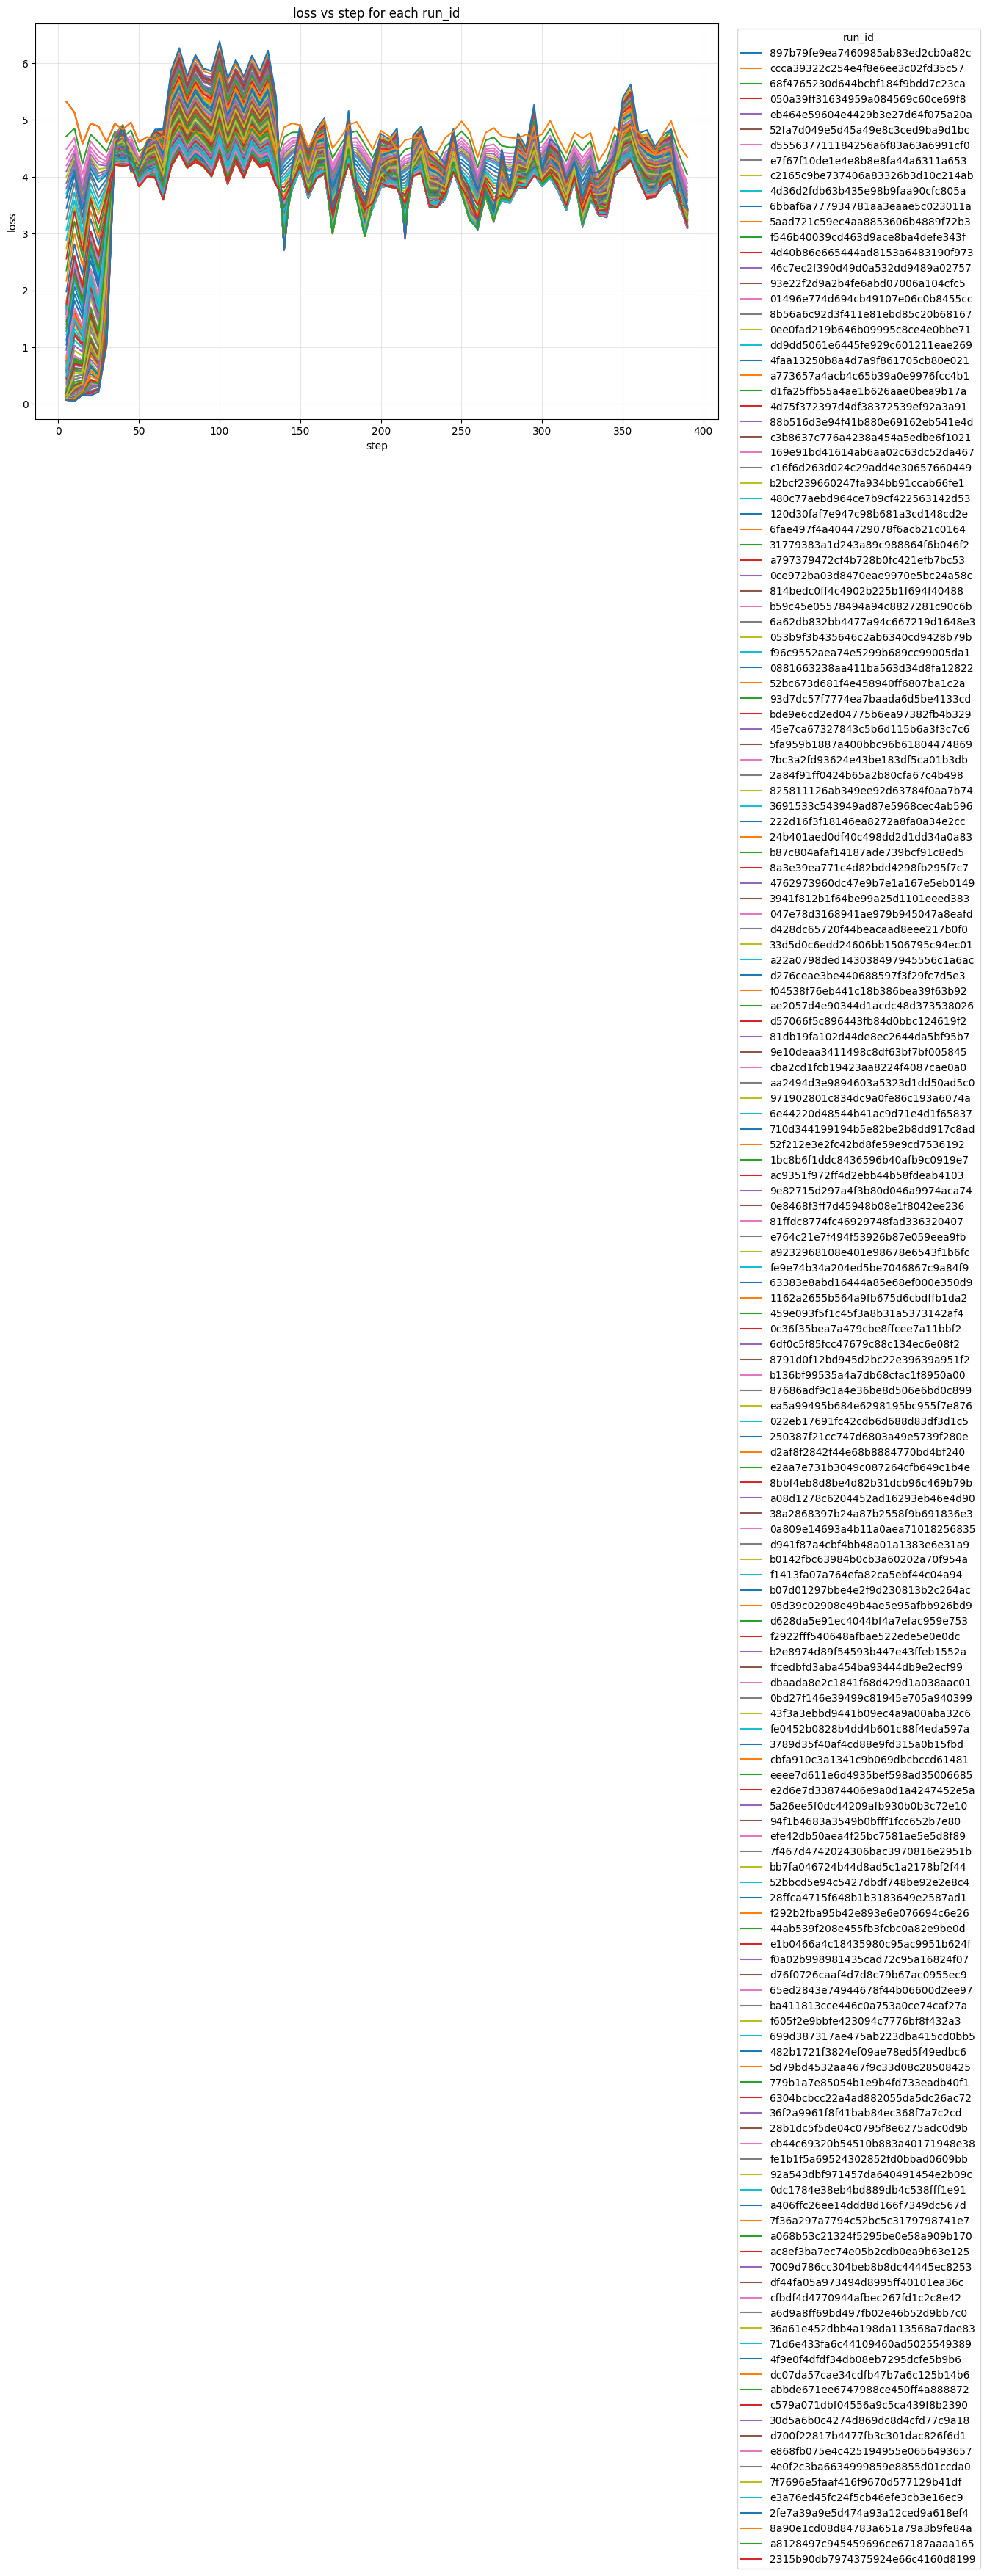

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'loss vs step for each run_id'}, xlabel='step', ylabel='loss'>)

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_metric_by_run(
    df: pd.DataFrame,
    target: str = "loss",
    step_col: str = "step",
    run_id_col: str = "run_id",
    figsize: tuple[int, int] = (12, 7),
):
    required = {run_id_col, step_col, target}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"В DataFrame нет колонок: {sorted(missing)}")

    plot_df = df[[run_id_col, step_col, target]].copy()
    plot_df[run_id_col] = plot_df[run_id_col].astype(str)
    # plot_df = plot_df.dropna(subset=[run_id_col, step_col, target])
    plot_df[step_col] = pd.to_numeric(plot_df[step_col], errors="coerce")
    plot_df[target] = pd.to_numeric(plot_df[target], errors="coerce")
    # plot_df = plot_df.dropna(subset=[step_col, target])
    plot_df = plot_df.sort_values(step_col)

    fig, ax = plt.subplots(figsize=figsize)
    for run_id, g in plot_df.groupby(run_id_col, sort=False):
        ax.plot(g[step_col], g[target], label=run_id, linewidth=1.5)

    ax.set_xlabel(step_col)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {step_col} for each {run_id_col}")
    ax.grid(True, alpha=0.3)
    ax.legend(title=run_id_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

    return fig, ax

# пример:
plot_metric_by_run(exp58_df, target="loss")
# plot_metric_by_run(exp58_df, target="perplexity")

/tmp/ipykernel_76846/2920835163.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


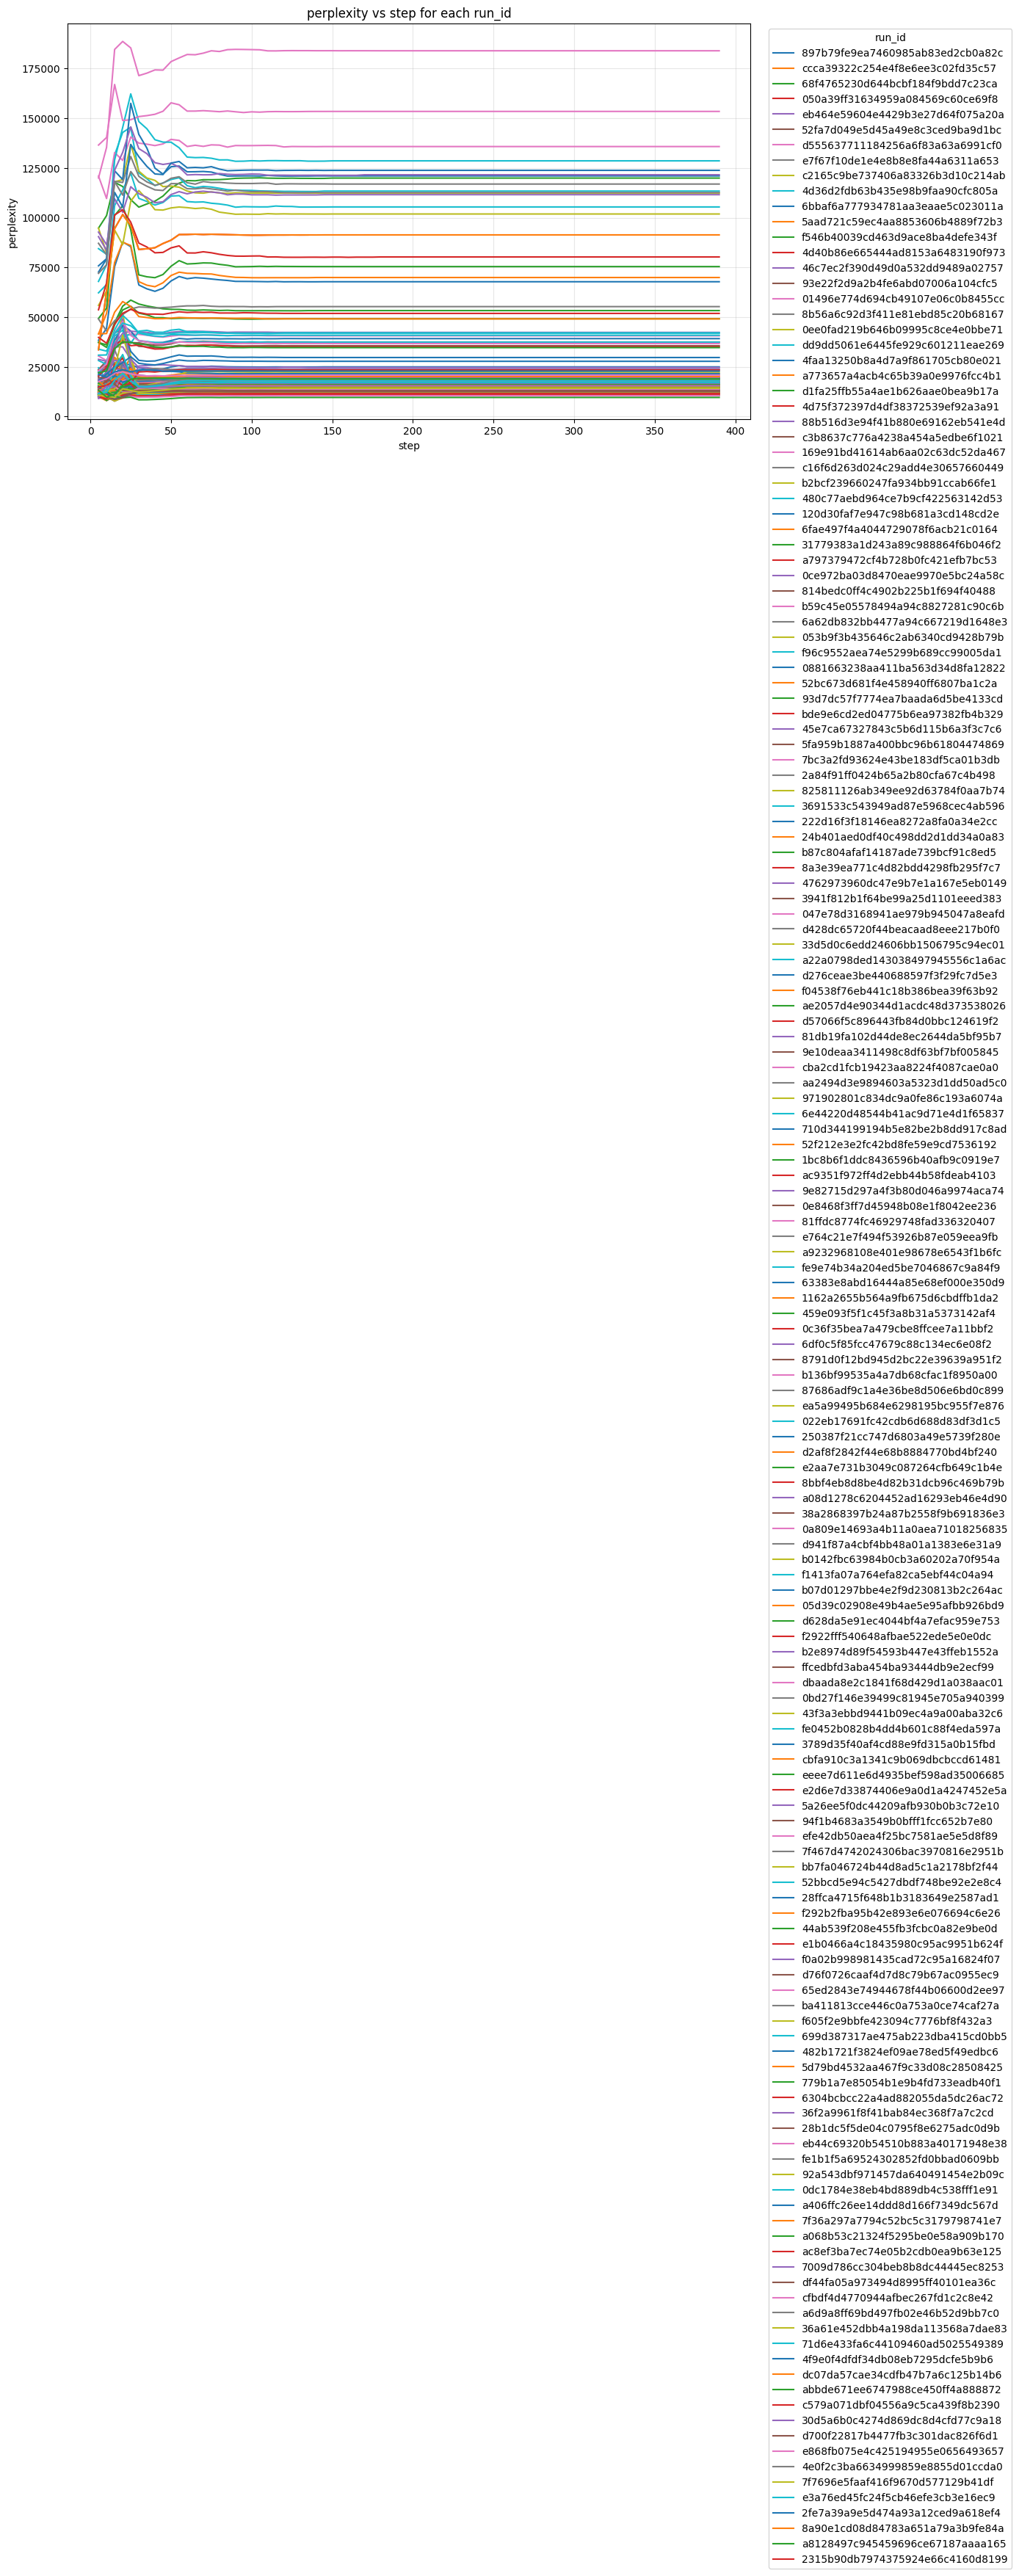

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'perplexity vs step for each run_id'}, xlabel='step', ylabel='perplexity'>)

In [136]:
plot_metric_by_run(exp58_df, target="perplexity")

In [29]:
exp58_df.columns

Index(['step', 'ug_next_update', 'ug_next_update_changed', 'cpu_percent',
       'gpu_memory_reserved_mb', 'gpu_memory_used_mb', 'perplexity', 'loss',
       'grad_norm', 'learning_rate', 'epoch', 'run_id', 'train_runtime',
       'train_samples_per_second', 'train_steps_per_second', 'total_flos',
       'train_loss'],
      dtype='object')

In [ ]:


runs = mlFlowClient.search_runs("58", filter_string=f"attributes.run_name LIKE 'parallel_tg_tiny_llm_%' AND attributes.created < {threshold}")
print(len(runs))
runs

167


[<Run: data=<RunData: metrics={'cpu_percent': 6.2,
  'epoch': 0.9230769230769231,
  'gpu_memory_reserved_mb': 8554.283008,
  'gpu_memory_used_mb': 8376.692736,
  'grad_norm': 24.277713775634766,
  'learning_rate': 1.0000000000000002e-07,
  'loss': 6.099595260620117,
  'perplexity': 20359.73046875,
  'ug_next_update': 130.0,
  'ug_next_update_changed': 0.0}, params={'_name_or_path': 'arnir0/Tiny-LLM',
  'accelerator_config': "{'split_batches': False, 'dispatch_batches': None, "
                        "'even_batches': True, 'use_seedable_sampler': True, "
                        "'non_blocking': False, 'gradient_accumulation_kwargs': "
                        'None}',
  'adam_beta1': '0.9',
  'adam_beta2': '0.999',
  'adam_epsilon': '1e-08',
  'architectures': "['LlamaForCausalLM']",
  'attention_bias': 'False',
  'attention_dropout': '0.0',
  'auto_find_batch_size': 'False',
  'average_tokens_across_devices': 'True',
  'batch_eval_metrics': 'False',
  'bf16': 'True',
  'bf16_full_eval'

In [83]:
runs_last = mlflow_converter.get_last_metrics_from_all_experiment_runs("58", filter_string=f"attributes.run_name LIKE 'parallel_tg_tiny_llm_%' AND attributes.created < {threshold}")

In [93]:
runs_last.sort_values("perplexity")

,run_id,ug_next_update,ug_next_update_changed,cpu_percent,gpu_memory_reserved_mb,gpu_memory_used_mb,perplexity,loss,grad_norm,learning_rate,epoch,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,a068b53c21324f5295be0e58a909b170,424.0,0.0,3.5,8621.391872,8376.098816,9603.765625,3.444935,56.809750,1.000000e-16,3.0,78.7431,19.697,4.953,3.261414e+13,4.181357
0,65ed2843e74944678f44b06600d2ee97,424.0,0.0,3.3,8621.391872,8376.098816,10487.619141,3.406467,51.267654,1.000000e-16,3.0,79.0057,19.631,4.936,3.261414e+13,4.159493
0,4762973960dc47e9b7e1a167e5eb0149,444.0,0.0,7.4,8621.391872,8376.098816,10533.022461,3.433881,54.821030,1.000000e-16,3.0,73.1103,21.215,5.334,3.261414e+13,4.142799
0,cbfa910c3a1341c9b069dbcbccd61481,411.0,0.0,4.0,8621.391872,8375.468032,10912.351562,3.331339,91.434494,1.000000e-16,3.0,76.5788,20.254,5.093,3.261414e+13,3.937800
0,52bbcd5e94c5427dbdf748be92e2e8c4,432.0,0.0,6.2,8619.294720,8376.098816,11051.629883,3.402324,46.667732,1.000000e-16,3.0,75.2679,20.606,5.181,3.261414e+13,4.214167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,cba2cd1fcb19423aa8224f4087cae0a0,432.0,0.0,6.1,8617.197568,8374.157312,153448.000000,3.810476,78.237801,1.000000e-16,3.0,73.3555,21.144,5.317,3.261414e+13,4.382954
0,0a809e14693a4b11a0aea71018256835,415.0,0.0,4.3,8617.197568,8374.157312,183943.234375,3.884399,68.887283,1.000000e-16,3.0,72.8987,21.276,5.350,3.261414e+13,4.443122
0,7b0908a20c224c10a86073c5c65a5f7a,0.0,0.0,4.9,12838.764544,12629.716992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,a1f90d78135b44e4a0659ce6d279d6a9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
runs_last.sort_values("loss")["ug_next_update"]

0    444.0
0    432.0
0    415.0
0    411.0
0    424.0
     ...  
0    158.0
0    130.0
0      0.0
0      NaN
0      0.0
Name: ug_next_update, Length: 167, dtype: float64